# Plot from Database Example

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine
from sqlmodel import Session, select

from cali.sqlmodel import ROI, Traces
from cali.sqlmodel._model import CaliResult

In [ ]:
database_path = "/Users/fdrgsp/Documents/git/cali/tests/test_data/data_and_db_for_tests/test_db.cali"  # noqa: E501
engine = create_engine(f"sqlite:///{database_path}")

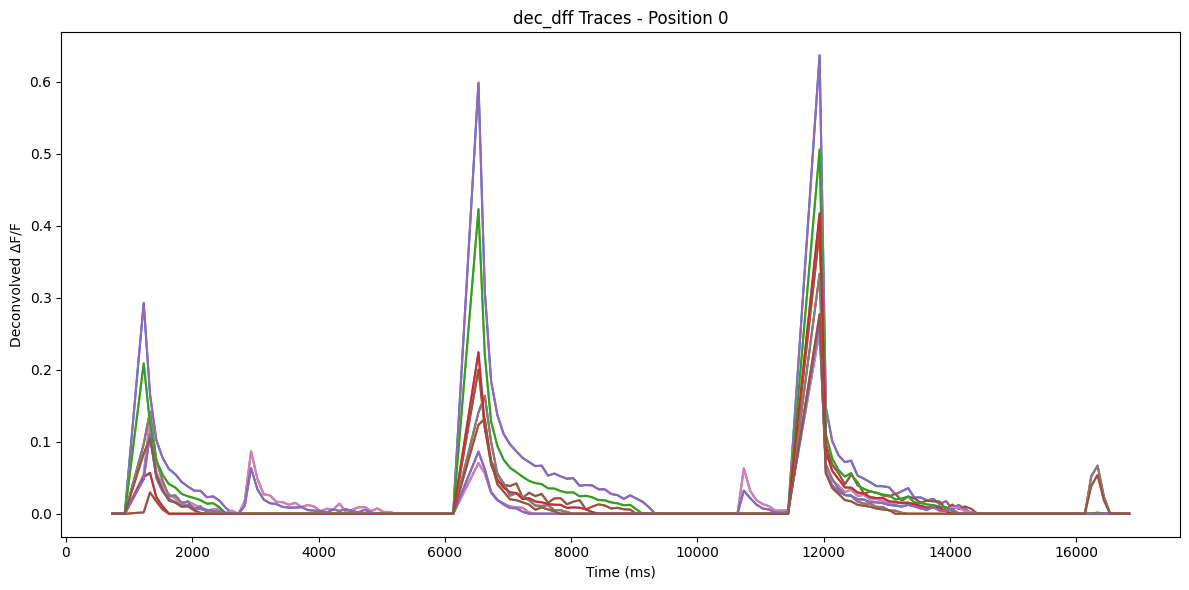

In [11]:
with Session(engine) as session:
    # Filter by detection settings ID (use None to get all)
    # Change this to filter by specific detection settings, or setto None for all
    detection_id = 1

    statement = select(Traces).join(ROI, Traces.roi_id == ROI.id)

    if detection_id is not None:
        statement = statement.join(CaliResult).where(
            CaliResult.detection_settings_id == detection_id
        )

    traces_list = session.exec(statement).all()

    # Plot all dec_dff traces
    fig, ax = plt.subplots(figsize=(12, 6))

    for trace in traces_list:
        tr = trace
        if trace.inferred_spikes is not None:
            # Use x_axis if available, otherwise use frame numbers
            x_data = (
                trace.x_axis
                if trace.x_axis is not None
                else list(range(len(trace.dec_dff)))
            )
            ax.plot(
                x_data,
                trace.inferred_spikes,
                # label=f"ROI {trace.roi.label_value}",
                # alpha=0.7,
            )

    x_label = "Time (ms)" if traces_list and traces_list[0].x_axis else "Frame"
    ax.set_xlabel(x_label)
    ax.set_ylabel("Deconvolved ΔF/F")
    ax.set_title("dec_dff Traces - Position 0")
    # ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

spike_times: [  4  53 103]

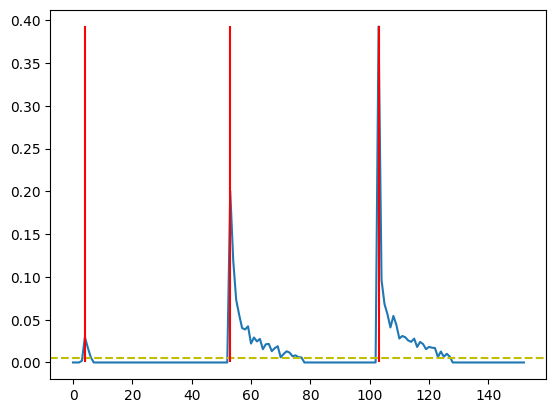

In [16]:
tr = traces_list[1]
inferred = np.asarray(tr.inferred_spikes, dtype=float)
th = 0.005
above = inferred > th
rising = above & ~np.concatenate(([False], above[:-1]))
spike_times = np.where(rising)[0]
print("spike_times:", spike_times)

t = np.arange(len(inferred))
plt.plot(t, inferred)
plt.axhline(th, ls="--", color="y")
plt.vlines(spike_times, inferred.min(), inferred.max(), color="r")
plt.show()